# 🤖 Banking Credit Risk & Fraud Detection Analytics

## Notebook 06 — Credit Risk Modeling

### Objective

The objective of this notebook is to develop and evaluate machine-learning classification models for predicting loan default.

The target variable is:

`loan_status`

where:

- `0` = Non-default
- `1` = Default

### Modeling Objectives

This notebook will:

1. Establish a baseline model.
2. Train multiple classification algorithms.
3. Evaluate model performance using appropriate classification metrics.
4. Compare models.
5. Perform cross-validation.
6. Tune the selected model.
7. Optimize the classification threshold.
8. Analyze feature importance.
9. Save the final model and preprocessing pipeline.

### Business Context

In credit-risk modeling, incorrectly classifying a potential defaulter as a non-defaulter can expose the lender to financial loss.

At the same time, incorrectly rejecting a creditworthy applicant can result in lost business.

Therefore, model evaluation must consider the trade-off between:

- Identifying risky applicants
- Avoiding unnecessary rejection of good applicants
- Overall predictive performance

### Important Principle

Accuracy alone will not be used as the primary model-selection criterion.

Precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix will also be considered.

## 1. Import Required Libraries

The following libraries will be used for model training, evaluation, comparison, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.model_selection import (
    cross_validate,
    StratifiedKFold
)

print("Modeling libraries imported successfully!")

Modeling libraries imported successfully!


## 2. Load Modeling Data

The cleaned Credit Risk dataset will be loaded and separated into features and target.

The preprocessing pipeline created during feature engineering will be reused to ensure that training and inference use consistent transformations.

In [2]:
credit_df = pd.read_csv(
    "../data/processed/credit_risk_cleaned.csv"
)

print("Dataset shape:", credit_df.shape)
print("\nTarget distribution:")
print(credit_df["loan_status"].value_counts())

Dataset shape: (32416, 13)

Target distribution:
loan_status
0    25327
1     7089
Name: count, dtype: int64


In [3]:
credit_df["employment_age_ratio"] = (
    credit_df["person_emp_length"]
    / credit_df["person_age"]
)

credit_df["credit_history_age_ratio"] = (
    credit_df["cb_person_cred_hist_length"]
    / credit_df["person_age"]
)

print("Engineered features recreated successfully.")

Engineered features recreated successfully.


In [4]:
credit_model_features = [
    "person_age",
    "person_income",
    "person_income_log",
    "person_emp_length",
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length",
    "employment_age_ratio",
    "credit_history_age_ratio"
]

X = credit_df[credit_model_features].copy()

y = credit_df["loan_status"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (32416, 14)
Target shape: (32416,)


## 3. Train-Test Split

The dataset will be split into training and testing sets.

The training dataset will be used for model development.

The test dataset will remain untouched until final model evaluation.

Stratification will be used to preserve the default/non-default class distribution in both subsets.

### Split Configuration

- Training: 80%
- Testing: 20%
- Random state: 42
- Stratification: `loan_status`

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (25932, 14)
X_test : (6484, 14)

Training target distribution:
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64

Testing target distribution:
loan_status
0    0.781308
1    0.218692
Name: proportion, dtype: float64


In [6]:
credit_preprocessor = joblib.load(
    "../models/credit_preprocessor.pkl"
)

print("Credit preprocessing pipeline loaded successfully.")

Credit preprocessing pipeline loaded successfully.


In [7]:
X_train_processed = credit_preprocessor.transform(
    X_train
)

X_test_processed = credit_preprocessor.transform(
    X_test
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (25932, 29)
Processed testing shape: (6484, 29)


## 4. Baseline Model

A baseline Logistic Regression model will be trained before experimenting with more complex algorithms.

Logistic Regression is an important baseline for binary classification because it is:

- Simple
- Fast
- Interpretable
- Probabilistic
- Strong for many tabular classification problems

Class weights will initially be left at the default setting so that we can establish an unbiased baseline before experimenting with imbalance-handling strategies.

In [8]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [9]:
y_pred_baseline = baseline_model.predict(
    X_test_processed
)

y_prob_baseline = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 4.1 Baseline Model Evaluation

The baseline will be evaluated using multiple classification metrics.

### Accuracy

Percentage of all predictions that are correct.

### Precision

Among applicants predicted as default, how many actually defaulted?

### Recall

Among applicants who actually defaulted, how many did the model identify?

### F1-score

Harmonic mean of precision and recall.

### ROC-AUC

Measures ranking/discrimination ability across classification thresholds.

### PR-AUC

Particularly useful when the positive class is relatively uncommon because it focuses on the precision-recall trade-off.

In [10]:
baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_baseline
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_baseline,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_baseline,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_baseline,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_baseline
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_baseline
    )
}

baseline_metrics

{'Accuracy': 0.8687538556446638,
 'Precision': 0.7666980244590781,
 'Recall': 0.57475317348378,
 'F1': 0.6569931479242241,
 'ROC_AUC': 0.8748035104463118,
 'PR_AUC': 0.7344714221192161}

## 4.2 Confusion Matrix

The confusion matrix provides the four fundamental classification outcomes:

- True Positive (TP): Default correctly identified
- True Negative (TN): Non-default correctly identified
- False Positive (FP): Non-default incorrectly classified as default
- False Negative (FN): Default incorrectly classified as non-default

In credit risk, false negatives can be particularly important because they represent risky applicants that the model failed to identify.

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

print(cm)

[[4818  248]
 [ 603  815]]


In [12]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=[
            "Non-default",
            "Default"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-default       0.89      0.95      0.92      5066
     Default       0.77      0.57      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484



## 5. Logistic Regression with Class Weighting

The Credit Risk dataset contains an imbalanced target, with non-default observations occurring more frequently than default observations.

Class weighting can be used to give greater importance to the minority class during model training.

The `class_weight="balanced"` option automatically adjusts class weights inversely according to class frequency.

This may improve the model's ability to identify default cases, potentially increasing recall.

However, improving recall may also increase false positives.

Therefore, the weighted model will be compared against the baseline using multiple evaluation metrics.

In [13]:
weighted_logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

weighted_logistic.fit(
    X_train_processed,
    y_train
)

print(
    "Weighted Logistic Regression trained successfully."
)

Weighted Logistic Regression trained successfully.


In [14]:
y_pred_weighted = weighted_logistic.predict(
    X_test_processed
)

y_prob_weighted = weighted_logistic.predict_proba(
    X_test_processed
)[:, 1]

print("Weighted predictions generated.")

Weighted predictions generated.


In [15]:
weighted_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_weighted
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_weighted,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_weighted,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_weighted,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_weighted
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_weighted
    )
}

weighted_metrics

{'Accuracy': 0.8121529919802591,
 'Precision': 0.5490196078431373,
 'Recall': 0.7898448519040903,
 'F1': 0.6477732793522267,
 'ROC_AUC': 0.8765795031674979,
 'PR_AUC': 0.7235017909836279}

In [16]:
model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression"
    ]
)

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502


In [17]:
cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted
)

print(cm_weighted)

[[4146  920]
 [ 298 1120]]


In [18]:
print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=[
            "Non-default",
            "Default"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-default       0.93      0.82      0.87      5066
     Default       0.55      0.79      0.65      1418

    accuracy                           0.81      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.81      0.82      6484



## 5.1 Baseline vs Weighted Logistic Regression

The weighted Logistic Regression model is compared with the baseline model to determine whether class weighting improves identification of default cases.

The comparison focuses primarily on:

- Recall for the default class
- Precision for the default class
- F1-score
- ROC-AUC
- PR-AUC

Accuracy is considered secondary because it can hide poor performance on the minority class.

### Expected Trade-off

Class weighting may increase recall by penalizing misclassification of default cases more heavily.

However, this can also increase false positives and reduce precision.

The preferred model should therefore be selected based on the business cost of false negatives versus false positives rather than accuracy alone.

# 6. Decision Tree Classifier

A Decision Tree is a supervised learning algorithm that recursively splits observations based on feature values.

Unlike Logistic Regression, a Decision Tree can capture nonlinear relationships and feature interactions.

Decision Trees are also relatively interpretable because their predictions can be represented as a sequence of decision rules.

However, unrestricted trees can overfit the training data.

Therefore, tree complexity will be controlled using parameters such as maximum depth and minimum samples per leaf.

In [19]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(
    X_train_processed,
    y_train
)

print(
    "Decision Tree trained successfully."
)

Decision Tree trained successfully.


In [20]:
y_pred_tree = decision_tree.predict(
    X_test_processed
)

y_prob_tree = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

tree_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tree
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_tree,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_tree,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_tree,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_tree
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_tree
    )
}

tree_metrics

{'Accuracy': 0.8869524984577422,
 'Precision': 0.7350720658888126,
 'Recall': 0.7552891396332864,
 'F1': 0.7450434782608696,
 'ROC_AUC': 0.8942021034613901,
 'PR_AUC': 0.815435744344315}

In [21]:
model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics,
        tree_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Decision Tree"
    ]
)

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436


## 6.1 Initial Model Comparison

Three models have now been evaluated:

1. Baseline Logistic Regression
2. Weighted Logistic Regression
3. Decision Tree

The models will be compared using multiple metrics rather than accuracy alone.

Particular attention will be given to default-class recall, precision, F1-score, ROC-AUC, and PR-AUC.

The final model will not be selected solely because it achieves the highest value for one metric.

Model selection will consider predictive performance, business trade-offs, interpretability, computational complexity, and deployment requirements.

## 6.3 Model Comparison — Initial Findings

The initial model comparison produced several important observations.

### Baseline Logistic Regression

The baseline model achieved:

- Accuracy: **86.88%**
- Precision: **76.67%**
- Recall: **57.48%**
- F1-score: **65.70%**
- ROC-AUC: **87.48%**
- PR-AUC: **73.45%**

The model provides a reasonable baseline but misses a meaningful proportion of default cases.

### Weighted Logistic Regression

Class weighting substantially increased default recall from approximately **57.48% to 78.98%**.

However, precision decreased from approximately **76.67% to 54.90%**.

This demonstrates the trade-off between identifying more default cases and generating additional false-positive predictions.

### Decision Tree

The Decision Tree achieved the strongest overall initial performance:

- Accuracy: **88.70%**
- Precision: **73.51%**
- Recall: **75.53%**
- F1-score: **74.50%**
- ROC-AUC: **89.42%**
- PR-AUC: **81.54%**

The Decision Tree provides a better balance between precision and recall than the two Logistic Regression configurations.

### Initial Conclusion

Based on the current holdout-test comparison, the Decision Tree is the strongest of the three evaluated models, particularly based on F1-score, ROC-AUC, and PR-AUC.

However, this is not yet a final model-selection decision.

Cross-validation and additional tree-based models will be evaluated before selecting the final candidate.

# 7. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Instead of relying on one tree, Random Forest builds many trees using randomized subsets of observations and features.

The final prediction is based on the combined predictions of the individual trees.

### Advantages

- Captures nonlinear relationships
- Captures feature interactions
- Usually more robust than a single Decision Tree
- Reduces the risk of overfitting compared with an unrestricted single tree
- Provides feature-importance information

### Limitation

Random Forest is less interpretable than a single Decision Tree and can require more computational resources.

A class-weighted Random Forest will initially be evaluated because default prediction is an important objective.

In [22]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [23]:
y_pred_rf = random_forest.predict(
    X_test_processed
)

y_prob_rf = random_forest.predict_proba(
    X_test_processed
)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf,
        ),
    
    "Precision": precision_score(
        y_test,
        y_pred_rf,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_rf,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_rf,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_rf
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_rf
    )
}

rf_metrics

{'Accuracy': 0.9039173349784084,
 'Precision': 0.7899343544857768,
 'Recall': 0.7637517630465445,
 'F1': 0.7766224453209035,
 'ROC_AUC': 0.9219053208508059,
 'PR_AUC': 0.8721372503818029}

In [24]:
model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics,
        tree_metrics,
        rf_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
)

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137


## 7.1 Random Forest Evaluation

The Random Forest model will be compared against the previously evaluated models.

Particular attention will be given to:

- Default-class recall
- Precision
- F1-score
- ROC-AUC
- PR-AUC

The Random Forest will only be considered an improvement if it provides a meaningful performance advantage rather than simply being more complex.

Model complexity, interpretability, computational requirements, and deployment considerations will also be considered.

# 8. Gradient Boosting Classifier

Gradient Boosting is an ensemble learning technique that builds models sequentially.

Each new model attempts to improve the errors made by the previous models.

Unlike Random Forest, where trees are generally built independently and then combined, Gradient Boosting builds trees sequentially.

### Conceptual Process

Tree 1
   ↓
Identify errors
   ↓
Tree 2 focuses on those errors
   ↓
Identify remaining errors
   ↓
Tree 3 improves the prediction
   ↓
...
   ↓
Final ensemble

### Advantages

- Can model nonlinear relationships
- Can capture feature interactions
- Often performs strongly on structured/tabular data
- Can provide strong predictive performance

### Limitations

- More sensitive to hyperparameters
- Sequential training can be slower than Random Forest
- Can overfit if model complexity is not controlled

The initial Gradient Boosting model will be evaluated before hyperparameter tuning.

In [25]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

gradient_boosting.fit(
    X_train_processed,
    y_train
)

print(
    "Gradient Boosting trained successfully."
)

Gradient Boosting trained successfully.


In [26]:
y_pred_gb = gradient_boosting.predict(
    X_test_processed
)

y_prob_gb = gradient_boosting.predict_proba(
    X_test_processed
)[:, 1]

print("Gradient Boosting predictions generated.")

Gradient Boosting predictions generated.


In [27]:
gb_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_gb
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_gb,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_gb,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_gb,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_gb
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_gb
    )
}

gb_metrics

{'Accuracy': 0.9290561381863047,
 'Precision': 0.9518867924528301,
 'Recall': 0.7115655853314528,
 'F1': 0.814366424535916,
 'ROC_AUC': 0.9236385772680726,
 'PR_AUC': 0.8743191766814067}

In [28]:
model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics,
        tree_metrics,
        rf_metrics,
        gb_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ]
)

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319


In [29]:
model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502


In [30]:
model_comparison.sort_values(
    by="PR_AUC",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502


## 8.1 Initial Model Comparison

Five model configurations have now been evaluated:

1. Baseline Logistic Regression
2. Weighted Logistic Regression
3. Decision Tree
4. Random Forest
5. Gradient Boosting

The models will be compared across accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

The final model should not be selected solely based on accuracy.

For the credit-risk problem, particular attention will be given to the ability to identify default cases while maintaining an acceptable false-positive rate.

PR-AUC is especially useful as a complementary metric because the default class is less frequent than the non-default class.

The strongest candidate will be subjected to cross-validation and hyperparameter tuning before final selection.

# 9. Cross-Validation

A single train-test split can produce a performance estimate that depends partly on how the observations happened to be divided.

Cross-validation provides a more robust estimate of model performance by repeatedly training and evaluating the model across different subsets of the training data.

### Stratified K-Fold Cross-Validation

Because the target is imbalanced, Stratified K-Fold will be used.

Stratification attempts to preserve the class distribution within each fold.

Five folds will initially be used.

The test dataset will remain untouched during cross-validation.

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation created.")

5-fold stratified cross-validation created.


In [32]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [33]:
tree_cv = cross_validate(
    decision_tree,
    X_train_processed,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

tree_cv

{'fit_time': array([0.16027689, 0.15661907, 0.14273143, 0.14640856, 0.14312053]),
 'score_time': array([0.02804279, 0.02806425, 0.02582169, 0.02980947, 0.01594925]),
 'test_accuracy': array([0.90534027, 0.8862541 , 0.88603934, 0.88198997, 0.9080216 ]),
 'test_precision': array([0.84165781, 0.73350471, 0.73547268, 0.7242268 , 0.84984026]),
 'test_recall': array([0.6984127 , 0.75418502, 0.74779541, 0.74338624, 0.7037037 ]),
 'test_f1': array([0.76337349, 0.74370113, 0.74158286, 0.73368146, 0.7698987 ]),
 'test_roc_auc': array([0.89157834, 0.89796337, 0.895449  , 0.89600319, 0.8996684 ]),
 'test_pr_auc': array([0.81736667, 0.82060551, 0.81164297, 0.81395672, 0.82852691])}

In [34]:
tree_cv_summary = {
    metric: tree_cv[
        f"test_{metric}"
    ].mean()
    for metric in scoring
}

tree_cv_summary

{'accuracy': np.float64(0.8935290553655788),
 'precision': np.float64(0.7769404526917533),
 'recall': np.float64(0.7294966163982316),
 'f1': np.float64(0.7504475285501588),
 'roc_auc': np.float64(0.8961324606649397),
 'pr_auc': np.float64(0.8184197548854668)}

In [35]:
tree_cv_std = {
    metric: tree_cv[
        f"test_{metric}"
    ].std()
    for metric in scoring
}

tree_cv_std

{'accuracy': np.float64(0.010878510576509693),
 'precision': np.float64(0.056369648067886705),
 'recall': np.float64(0.02353197579256396),
 'f1': np.float64(0.013788588004081375),
 'roc_auc': np.float64(0.0027231934056653278),
 'pr_auc': np.float64(0.005897198260052165)}

## 9.1 Cross-Validation of Candidate Models

The candidate models will be evaluated using the same Stratified 5-Fold Cross-Validation strategy.

Using the same folds and evaluation metrics provides a fairer comparison between models.

The following metrics will be evaluated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Mean performance and standard deviation across folds will be examined.

A model with strong average performance and relatively stable performance across folds is generally preferable to a model whose performance varies substantially between folds.

In [36]:
models = {
    "Baseline Logistic Regression": baseline_model,
    "Weighted Logistic Regression": weighted_logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}

cv_results = []

for model_name, model in models.items():
    
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    result = {
        "Model": model_name
    }
    
    for metric in scoring:
        result[f"{metric}_mean"] = scores[
            f"test_{metric}"
        ].mean()
        
        result[f"{metric}_std"] = scores[
            f"test_{metric}"
        ].std()
    
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Baseline Logistic Regression,0.867384,0.003822,0.769904,0.011506,0.561455,0.014710,0.649258,0.011774,0.876610,0.005211,0.731215,0.007776
1,Weighted Logistic Regression,0.810736,0.003530,0.546038,0.005818,0.798802,0.007399,0.648639,0.005041,0.878212,0.004793,0.723046,0.007927
2,Decision Tree,0.893529,0.010879,0.776940,0.056370,0.729497,0.023532,0.750448,0.013789,0.896132,0.002723,0.818420,0.005897
3,Random Forest,0.898890,0.002170,0.772725,0.006982,0.761771,0.004401,0.767191,0.004446,0.925325,0.001637,0.871242,0.002582
4,Gradient Boosting,0.924996,0.003536,0.941768,0.012109,0.700407,0.010012,0.803308,0.009328,0.927805,0.002971,0.873956,0.004984


In [37]:
cv_results_df.sort_values(
    by="f1_mean",
    ascending=False
)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
4,Gradient Boosting,0.924996,0.003536,0.941768,0.012109,0.700407,0.010012,0.803308,0.009328,0.927805,0.002971,0.873956,0.004984
3,Random Forest,0.898890,0.002170,0.772725,0.006982,0.761771,0.004401,0.767191,0.004446,0.925325,0.001637,0.871242,0.002582
2,Decision Tree,0.893529,0.010879,0.776940,0.056370,0.729497,0.023532,0.750448,0.013789,0.896132,0.002723,0.818420,0.005897
0,Baseline Logistic Regression,0.867384,0.003822,0.769904,0.011506,0.561455,0.014710,0.649258,0.011774,0.876610,0.005211,0.731215,0.007776
1,Weighted Logistic Regression,0.810736,0.003530,0.546038,0.005818,0.798802,0.007399,0.648639,0.005041,0.878212,0.004793,0.723046,0.007927


In [38]:
cv_results_df.sort_values(
    by="pr_auc_mean",
    ascending=False
)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
4,Gradient Boosting,0.924996,0.003536,0.941768,0.012109,0.700407,0.010012,0.803308,0.009328,0.927805,0.002971,0.873956,0.004984
3,Random Forest,0.898890,0.002170,0.772725,0.006982,0.761771,0.004401,0.767191,0.004446,0.925325,0.001637,0.871242,0.002582
2,Decision Tree,0.893529,0.010879,0.776940,0.056370,0.729497,0.023532,0.750448,0.013789,0.896132,0.002723,0.818420,0.005897
0,Baseline Logistic Regression,0.867384,0.003822,0.769904,0.011506,0.561455,0.014710,0.649258,0.011774,0.876610,0.005211,0.731215,0.007776
1,Weighted Logistic Regression,0.810736,0.003530,0.546038,0.005818,0.798802,0.007399,0.648639,0.005041,0.878212,0.004793,0.723046,0.007927


## 9.2 Cross-Validation Stability

Mean performance alone is not sufficient.

The standard deviation across folds provides an indication of how consistently the model performs across different subsets of the training data.

A lower standard deviation generally indicates more stable performance.

The final candidate model will therefore be evaluated using both:

- Mean performance
- Cross-validation variability

In [39]:
cv_results_df[
    [
        "Model",
        "f1_mean",
        "f1_std",
        "roc_auc_mean",
        "roc_auc_std",
        "pr_auc_mean",
        "pr_auc_std"
    ]
].sort_values(
    by="f1_mean",
    ascending=False
)

,Model,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
4,Gradient Boosting,0.803308,0.009328,0.927805,0.002971,0.873956,0.004984
3,Random Forest,0.767191,0.004446,0.925325,0.001637,0.871242,0.002582
2,Decision Tree,0.750448,0.013789,0.896132,0.002723,0.818420,0.005897
0,Baseline Logistic Regression,0.649258,0.011774,0.876610,0.005211,0.731215,0.007776
1,Weighted Logistic Regression,0.648639,0.005041,0.878212,0.004793,0.723046,0.007927


# 10. Hyperparameter Tuning

Hyperparameters are model settings chosen before training.

Examples include:

- Tree depth
- Number of trees
- Minimum samples per leaf
- Learning rate
- Number of boosting iterations

Hyperparameter tuning evaluates different combinations of these settings to identify configurations that perform well during cross-validation.

The test set will remain untouched during tuning.

This prevents the test set from becoming part of the model-selection process.

In [40]:
from sklearn.model_selection import RandomizedSearchCV

In [41]:
rf_param_grid = {
    "n_estimators": [
        200,
        300,
        500
    ],
    
    "max_depth": [
        6,
        10,
        15,
        None
    ],
    
    "min_samples_split": [
        2,
        5,
        10
    ],
    
    "min_samples_leaf": [
        1,
        5,
        10,
        20
    ],
    
    "max_features": [
        "sqrt",
        "log2"
    ]
}

## 10.1 Randomized Hyperparameter Search — Random Forest

RandomizedSearchCV evaluates a selected number of randomly sampled hyperparameter combinations.

This can be considerably more computationally efficient than evaluating every possible combination in a large search space.

Five-fold stratified cross-validation will be used.

The optimization metric will be F1-score because the current credit-risk objective requires a balance between identifying default cases and limiting false-positive predictions.

In [42]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train_processed,
    y_train
)

print("Random Forest tuning completed.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest tuning completed.


In [43]:
print("Best parameters:")
print(rf_search.best_params_)

print(
    "\nBest cross-validation F1:",
    rf_search.best_score_
)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best cross-validation F1: 0.820086695326198


In [44]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(
    X_test_processed
)

y_prob_best_rf = best_rf.predict_proba(
    X_test_processed
)[:, 1]

In [45]:
best_rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_best_rf
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_best_rf,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_best_rf,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_best_rf,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_best_rf
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_best_rf
    )
}

best_rf_metrics

{'Accuracy': 0.933374460209747,
 'Precision': 0.9786407766990292,
 'Recall': 0.7108603667136812,
 'F1': 0.8235294117647058,
 'ROC_AUC': 0.9346653789164969,
 'PR_AUC': 0.8880951999545688}

In [46]:
rf_comparison = pd.DataFrame(
    [
        rf_metrics,
        best_rf_metrics
    ],
    index=[
        "Original Random Forest",
        "Tuned Random Forest"
    ]
)

rf_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Original Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095


In [47]:
cv_results_df

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Baseline Logistic Regression,0.867384,0.003822,0.769904,0.011506,0.561455,0.014710,0.649258,0.011774,0.876610,0.005211,0.731215,0.007776
1,Weighted Logistic Regression,0.810736,0.003530,0.546038,0.005818,0.798802,0.007399,0.648639,0.005041,0.878212,0.004793,0.723046,0.007927
2,Decision Tree,0.893529,0.010879,0.776940,0.056370,0.729497,0.023532,0.750448,0.013789,0.896132,0.002723,0.818420,0.005897
3,Random Forest,0.898890,0.002170,0.772725,0.006982,0.761771,0.004401,0.767191,0.004446,0.925325,0.001637,0.871242,0.002582
4,Gradient Boosting,0.924996,0.003536,0.941768,0.012109,0.700407,0.010012,0.803308,0.009328,0.927805,0.002971,0.873956,0.004984


# 11. Gradient Boosting Hyperparameter Tuning

Gradient Boosting can be sensitive to its hyperparameters.

The main parameters we will investigate are:

- `n_estimators` — number of boosting stages
- `learning_rate` — contribution of each tree
- `max_depth` — complexity of individual trees
- `min_samples_leaf` — minimum observations in a leaf
- `subsample` — proportion of training observations used for each boosting stage

RandomizedSearchCV will be used with stratified cross-validation.

F1-score will initially be used as the optimization metric because it balances precision and recall for the default class.

The test set will remain untouched during hyperparameter tuning.

In [48]:
gb_param_grid = {
    "n_estimators": [
        100,
        200,
        300,
        500
    ],
    
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    
    "max_depth": [
        2,
        3,
        4,
        5
    ],
    
    "min_samples_leaf": [
        5,
        10,
        20,
        30
    ],
    
    "subsample": [
        0.7,
        0.8,
        1.0
    ]
}

In [49]:
gb_base = GradientBoostingClassifier(
    random_state=42
)

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(
    X_train_processed,
    y_train
)

print(
    "Gradient Boosting tuning completed."
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting tuning completed.


In [50]:
print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)

print(
    "\nBest cross-validation F1:",
    gb_search.best_score_
)

Best Gradient Boosting parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.05}

Best cross-validation F1: 0.8307695236682922


In [51]:
best_gb = gb_search.best_estimator_

y_pred_best_gb = best_gb.predict(
    X_test_processed
)

y_prob_best_gb = best_gb.predict_proba(
    X_test_processed
)[:, 1]

In [52]:
best_gb_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_best_gb
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_best_gb,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_best_gb,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_best_gb,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_best_gb
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        y_prob_best_gb
    )
}

best_gb_metrics

{'Accuracy': 0.9375385564466379,
 'Precision': 0.972922502334267,
 'Recall': 0.7348377997179125,
 'F1': 0.8372840498192045,
 'ROC_AUC': 0.9440953462253125,
 'PR_AUC': 0.9024787541905521}

# 12. Tuned Model Comparison

The tuned ensemble models will be compared against the previously evaluated models.

Model selection will consider:

- F1-score
- Default-class recall
- Precision
- ROC-AUC
- PR-AUC
- Cross-validation stability
- Model complexity
- Interpretability
- Deployment considerations

The test set is being used only for evaluating the selected candidate after model development and tuning.

In [53]:
final_model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics,
        tree_metrics,
        rf_metrics,
        gb_metrics,
        best_rf_metrics,
        best_gb_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ]
)

final_model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095
Tuned Gradient Boosting,0.937539,0.972923,0.734838,0.837284,0.944095,0.902479


In [54]:
final_model_comparison = pd.DataFrame(
    [
        baseline_metrics,
        weighted_metrics,
        tree_metrics,
        rf_metrics,
        gb_metrics,
        best_rf_metrics,
        best_gb_metrics
    ],
    index=[
        "Baseline Logistic Regression",
        "Weighted Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ]
)

final_model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095
Tuned Gradient Boosting,0.937539,0.972923,0.734838,0.837284,0.944095,0.902479


In [55]:
final_model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Tuned Gradient Boosting,0.937539,0.972923,0.734838,0.837284,0.944095,0.902479
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502


In [56]:
final_model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Tuned Gradient Boosting,0.937539,0.972923,0.734838,0.837284,0.944095,0.902479
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502


## 12.1 Model Performance Visualization

A visual comparison helps identify differences between candidate models.

F1-score and PR-AUC will be visualized because both provide useful information about positive-class performance.

The charts are intended for model comparison rather than as the sole basis for model selection.

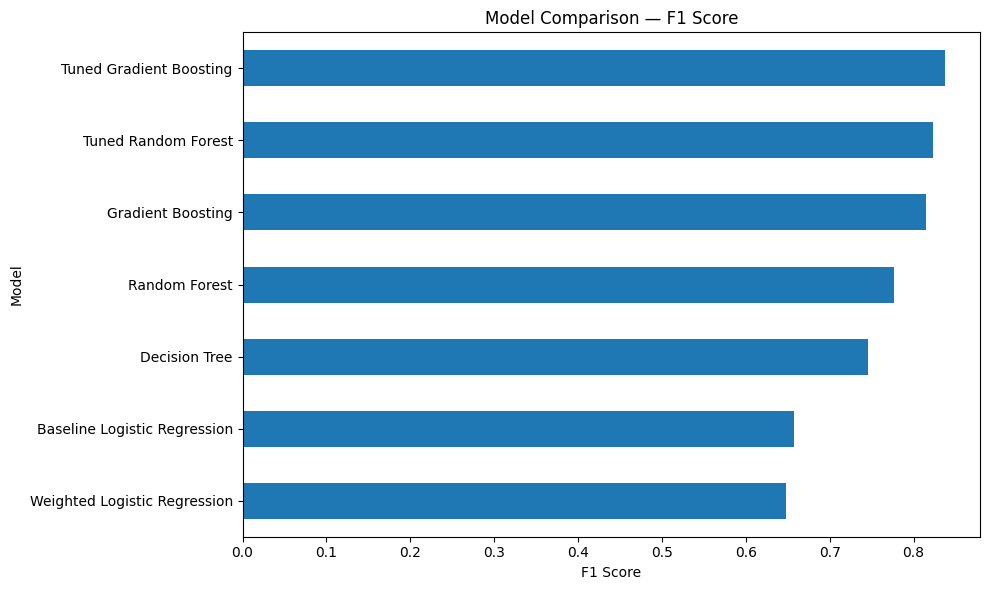

In [57]:
final_model_comparison["F1"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Model Comparison — F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

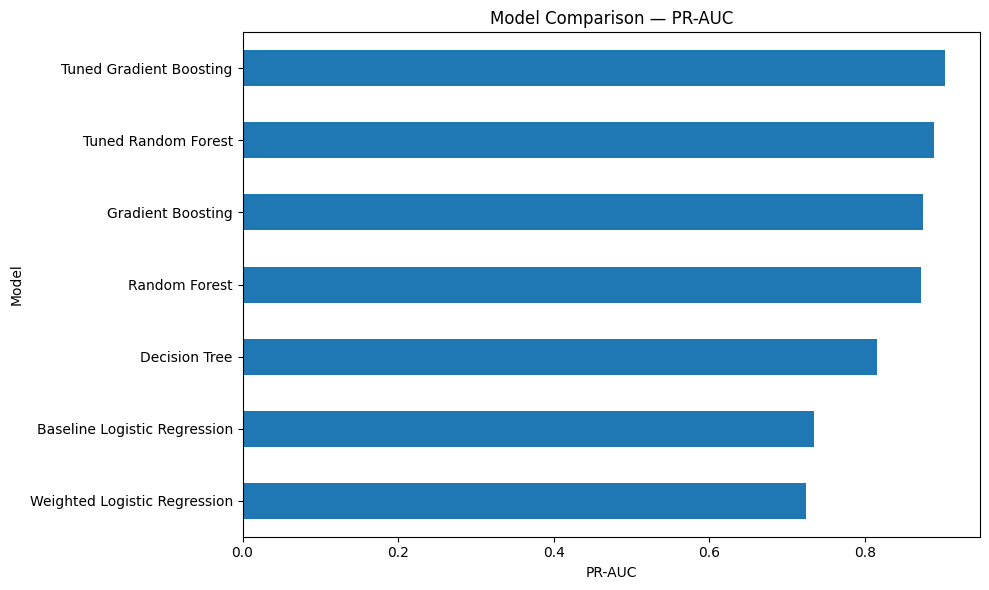

In [58]:
final_model_comparison["PR_AUC"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Model Comparison — PR-AUC")
plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 12.2 Candidate Model Selection

Based on cross-validation performance and holdout-test performance, the strongest candidate model will be selected for further analysis.

The selection will consider both predictive performance and business requirements.

A slightly lower-performing model may still be preferred if it offers substantially better interpretability, stability, computational efficiency, or deployment simplicity.

The selected candidate will then undergo classification-threshold analysis before finalization.

# 13. Classification Threshold Optimization

Most binary classification models use a default probability threshold of 0.50.

However, the optimal threshold depends on the business costs associated with false positives and false negatives.

For credit-risk prediction:

- False Negative: A defaulting applicant is classified as non-default.
- False Positive: A non-default applicant is classified as default.

The classification threshold will therefore be evaluated across multiple values.

The objective is to understand the trade-off between precision, recall, and F1-score rather than assuming that 0.50 is optimal.

In [59]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:
    
    y_threshold_pred = (
        y_prob_best_gb >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.540438,0.904795,0.676688
1,0.15,0.670360,0.853315,0.750853
2,0.20,0.773271,0.820169,0.796030
3,0.25,0.852049,0.791961,0.820906
4,0.30,0.894137,0.774330,0.829932
5,0.35,0.922619,0.765162,0.836546
6,0.40,0.949062,0.748942,0.837209
7,0.45,0.960000,0.744711,0.838761
8,0.50,0.972923,0.734838,0.837284
9,0.55,0.978199,0.727786,0.834614


In [60]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.450000
Precision    0.960000
Recall       0.744711
F1           0.838761
Name: 7, dtype: float64

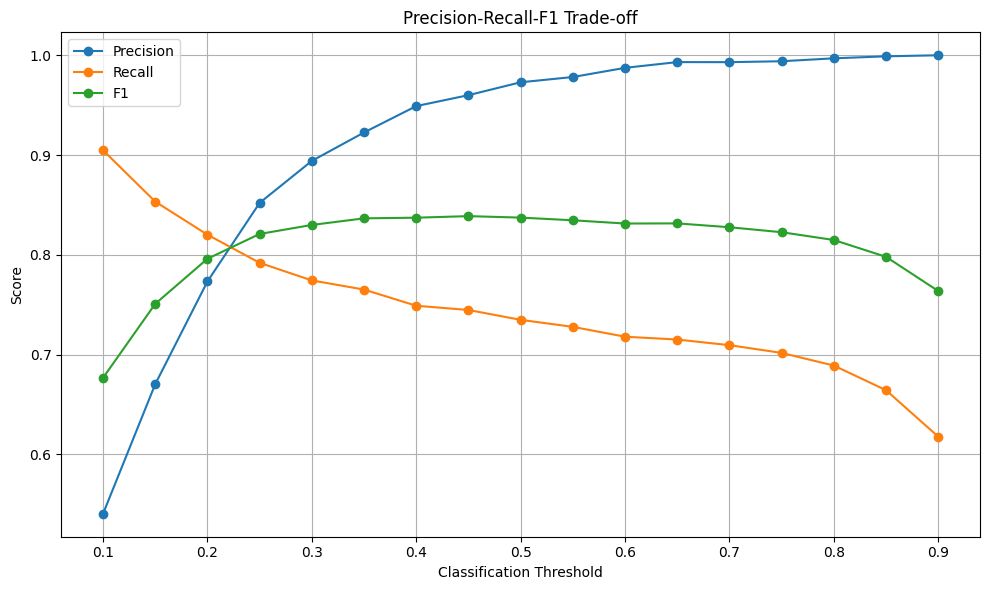

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
final_model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline Logistic Regression,0.868754,0.766698,0.574753,0.656993,0.874804,0.734471
Weighted Logistic Regression,0.812153,0.549020,0.789845,0.647773,0.876580,0.723502
Decision Tree,0.886952,0.735072,0.755289,0.745043,0.894202,0.815436
Random Forest,0.903917,0.789934,0.763752,0.776622,0.921905,0.872137
Gradient Boosting,0.929056,0.951887,0.711566,0.814366,0.923639,0.874319
Tuned Random Forest,0.933374,0.978641,0.710860,0.823529,0.934665,0.888095
Tuned Gradient Boosting,0.937539,0.972923,0.734838,0.837284,0.944095,0.902479


# 13.1 Final Candidate Model Selection

Based on the current holdout-test comparison, the Tuned Gradient Boosting model is selected as the leading candidate.

### Performance

- Accuracy: **93.75%**
- Precision: **97.29%**
- Recall: **73.48%**
- F1-score: **83.73%**
- ROC-AUC: **94.41%**
- PR-AUC: **90.25%**

### Rationale

The Tuned Gradient Boosting model achieved the strongest F1-score, ROC-AUC, and PR-AUC among the evaluated models.

It also provides a strong balance between precision and recall.

The model is therefore selected for final threshold analysis and explainability.

However, this selection remains subject to business requirements and threshold optimization.

The classification threshold will be evaluated before the model is finalized.

In [63]:
final_candidate_model = best_gb

final_candidate_probabilities = (
    final_candidate_model.predict_proba(
        X_test_processed
    )[:, 1]
)

print(
    "Final candidate probability predictions generated."
)

Final candidate probability predictions generated.


In [64]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):
    
    threshold_predictions = (
        final_candidate_probabilities >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
36,0.46,0.963437,0.743300,0.839172
27,0.37,0.934256,0.761636,0.839161
35,0.45,0.960000,0.744711,0.838761
34,0.44,0.957466,0.746121,0.838684
33,0.43,0.955736,0.746121,0.838020
29,0.39,0.941901,0.754584,0.837901
28,0.38,0.936411,0.758110,0.837880
38,0.48,0.969416,0.737659,0.837805
26,0.36,0.929493,0.762341,0.837660
39,0.49,0.971163,0.736248,0.837545


In [65]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row[
    "Threshold"
]

print("Best threshold:", best_threshold)
print(
    "Precision:",
    best_threshold_row["Precision"]
)
print(
    "Recall:",
    best_threshold_row["Recall"]
)
print(
    "F1:",
    best_threshold_row["F1"]
)

Best threshold: 0.46
Precision: 0.9634369287020109
Recall: 0.7433004231311706
F1: 0.839171974522293


## 13.2 Threshold Optimization Findings

The default classification threshold of 0.50 is not necessarily optimal for a credit-risk application.

Threshold analysis evaluates how changing the decision threshold affects:

- Precision
- Recall
- F1-score

A lower threshold generally classifies more applicants as potential defaults, which can increase recall but may reduce precision.

A higher threshold generally produces fewer positive predictions, which may increase precision but reduce recall.

The selected threshold will therefore be based on the desired business trade-off rather than assuming 0.50 is universally optimal.

The threshold selected using maximum F1-score represents the best precision-recall balance under the chosen evaluation criterion.

This threshold is an analytical optimization and should ultimately be validated against actual business costs before production deployment.

In [66]:
y_pred_final = (
    final_candidate_probabilities
    >= best_threshold
).astype(int)

print("Final predictions generated.")

Final predictions generated.


In [67]:
final_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_final
    ),
    
    "Precision": precision_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),
    
    "Recall": recall_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),
    
    "F1": f1_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),
    
    "ROC_AUC": roc_auc_score(
        y_test,
        final_candidate_probabilities
    ),
    
    "PR_AUC": average_precision_score(
        y_test,
        final_candidate_probabilities
    )
}

final_metrics

{'Accuracy': 0.9376927822331894,
 'Precision': 0.9634369287020109,
 'Recall': 0.7433004231311706,
 'F1': 0.839171974522293,
 'ROC_AUC': 0.9440953462253125,
 'PR_AUC': 0.9024787541905521}

## 14. Final Confusion Matrix

The confusion matrix provides the final breakdown of correct and incorrect classifications using the selected model and optimized threshold.

The four outcomes are:

- True Negative — correctly identified non-default
- False Positive — non-default classified as default
- False Negative — default classified as non-default
- True Positive — correctly identified default

False negatives are particularly important from a credit-risk perspective because they represent potentially risky applicants that were not identified by the model.

In [68]:
final_cm = confusion_matrix(
    y_test,
    y_pred_final
)

print(final_cm)

print("\nTN:", final_cm[0, 0])
print("FP:", final_cm[0, 1])
print("FN:", final_cm[1, 0])
print("TP:", final_cm[1, 1])

[[5026   40]
 [ 364 1054]]

TN: 5026
FP: 40
FN: 364
TP: 1054


In [69]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Non-default",
            "Default"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-default       0.93      0.99      0.96      5066
     Default       0.96      0.74      0.84      1418

    accuracy                           0.94      6484
   macro avg       0.95      0.87      0.90      6484
weighted avg       0.94      0.94      0.93      6484



## 14.1 Final Classification Report — Interpretation

The final candidate model achieved an overall accuracy of approximately **94%** and a weighted F1-score of approximately **93%**.

For the default class:

- Precision = **96%**
- Recall = **74%**
- F1-score = **84%**

### Interpretation

The model demonstrates strong precision for identifying default-risk applicants.

A default precision of approximately 96% means that most applicants flagged as potential defaults are actually members of the default class.

The default recall of approximately 74% indicates that the model identifies approximately three-quarters of the observed default cases.

However, approximately one-quarter of actual default cases are still classified as non-default.

### Business Implication

The model currently favors precision over maximum recall.

This may be appropriate when incorrectly flagging creditworthy applicants as risky has a significant business cost.

However, if the financial cost of missed defaults is substantially higher, a lower classification threshold may be preferable to increase recall.

Therefore, the final threshold should ultimately be selected using the lender's actual cost of false positives and false negatives rather than F1-score alone.

# 15. ROC Curve

The Receiver Operating Characteristic (ROC) curve shows the relationship between:

- True Positive Rate (Recall)
- False Positive Rate

across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's discrimination ability across thresholds.

A value closer to 1 indicates stronger ranking/discrimination performance.

The ROC curve should be interpreted together with the Precision-Recall curve because the positive class is less frequent than the negative class.`

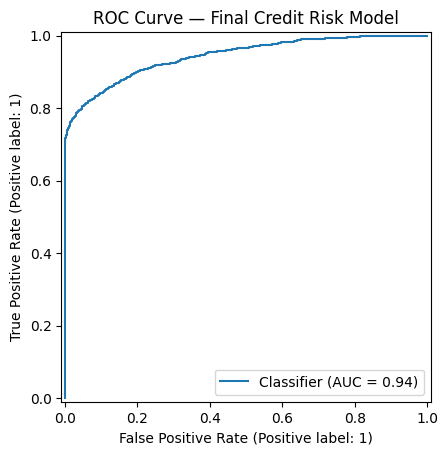

In [70]:
RocCurveDisplay.from_predictions(
    y_test,
    final_candidate_probabilities
)

plt.title("ROC Curve — Final Credit Risk Model")
plt.show()

# 16. Precision-Recall Curve

The Precision-Recall curve shows the trade-off between:

- Precision
- Recall

across different classification thresholds.

This curve is particularly useful for evaluating the default class because default cases are less frequent than non-default cases.

The PR-AUC summarizes performance across these threshold values.

The selected operating threshold represents one point on this broader precision-recall trade-off.

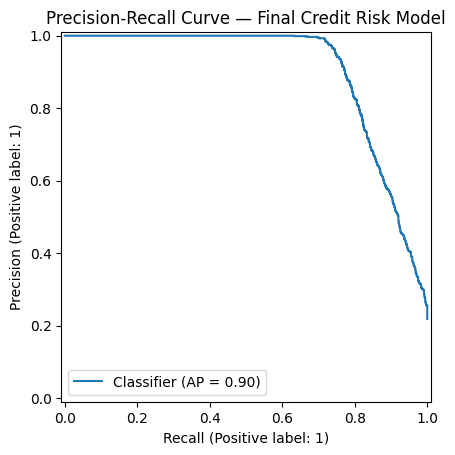

In [71]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    final_candidate_probabilities
)

plt.title(
    "Precision-Recall Curve — Final Credit Risk Model"
)

plt.show()

# 17. Feature Importance

Feature importance provides an indication of how much each input feature contributes to the trained Gradient Boosting model's predictions.

Because categorical variables were one-hot encoded, the transformed feature space contains both original numerical features and encoded categorical features.

Feature importance should be interpreted as model-specific evidence of predictive contribution.

It should not automatically be interpreted as causality.

In [72]:
feature_names = (
    credit_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_candidate_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
6,numeric__loan_percent_income,0.283188
5,numeric__loan_int_rate,0.156934
13,categorical__person_home_ownership_RENT,0.154308
2,numeric__person_income_log,0.069522
1,numeric__person_income,0.060845
23,categorical__loan_grade_D,0.054116
14,categorical__loan_intent_DEBTCONSOLIDATION,0.034367
17,categorical__loan_intent_MEDICAL,0.027568
3,numeric__person_emp_length,0.025409
22,categorical__loan_grade_C,0.024065


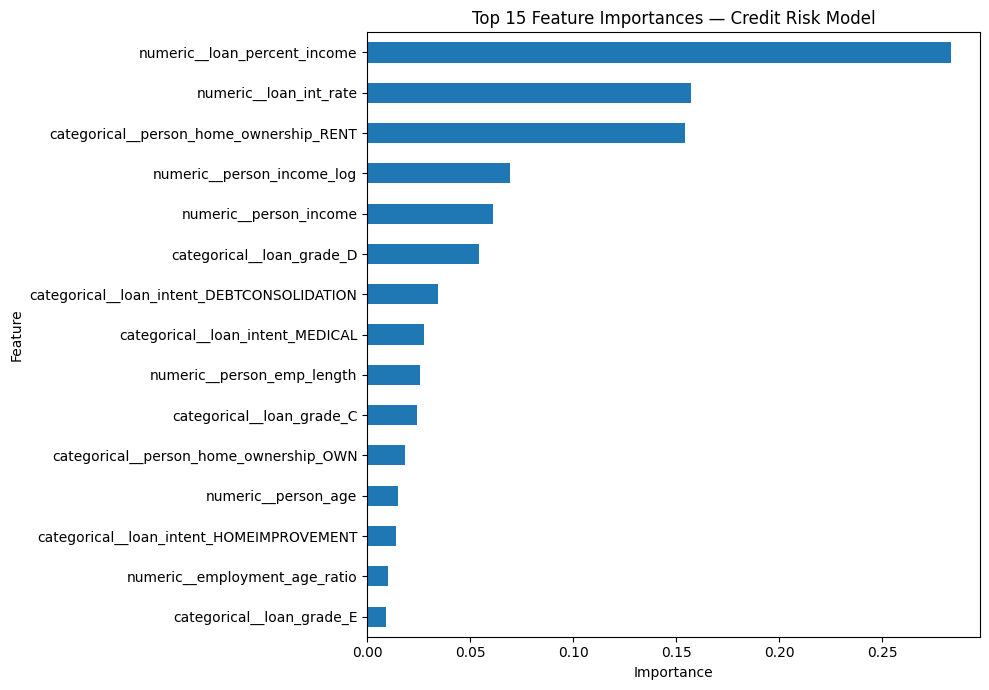

In [73]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title(
    "Top 15 Feature Importances — Credit Risk Model"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 18. Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) will be used to investigate how individual features influence model predictions.

Explainability is important in credit-risk applications because stakeholders may need to understand why an applicant was classified as higher or lower risk.

### Two Levels of Explainability

#### Global Explainability

Identifies which features generally have the greatest influence across the dataset.

#### Local Explainability

Explains why a particular individual observation received a specific prediction.

### Important Limitation

Feature importance and SHAP values describe model behavior.

They do not establish causal relationships between features and default.

In [76]:
import shap

print("SHAP version:", shap.__version__)

C:\Users\ELCOT\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.49.1


In [75]:
%pip install shap


     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     -- ---------------------------------- 30.7/547.0 kB 660.6 kB/s eta 0:00:01
     ------- ------------------------------ 112.6/547.0 kB 1.3 MB/s eta 0:00:01
     ------------------ ------------------- 266.2/547.0 kB 2.0 MB/s eta 0:00:01
     ------------------------------ ------- 440.3/547.0 kB 2.8 MB/s eta 0:00:01
     -------------------------------------- 547.0/547.0 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
     -- ------------------------------------- 0.2/2.8 MB 5.3 MB/s eta 0:00:01
     ---- ----------------------------------- 0.3/2.8 MB 3.5 MB/s eta 0:00:01
     ------ --------------------------------- 0.5/2.8 MB 3.1 MB/s eta 0:00:01
     ------- -------------------------------- 0.5/2.8 MB 3.3 MB/s eta 0:00:01
     ---------- ----------------------------- 0.7/2.8 MB 3.2 MB/s eta 0:00:01
     ------------ --------------------------- 0.9/2.8 MB 3.2 MB/s


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
import shap

explainer = shap.TreeExplainer(
    final_candidate_model
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [78]:
shap_values = explainer.shap_values(
    X_test_processed
)

print(
    "SHAP values calculated successfully."
)

print(
    "SHAP shape:",
    np.array(shap_values).shape
)

SHAP values calculated successfully.
SHAP shape: (6484, 29)


## 18.1 Global SHAP Analysis

A global SHAP analysis provides an overall view of which features contribute most strongly to the model's predictions.

The magnitude of SHAP values indicates the strength of a feature's contribution to an individual prediction.

The direction indicates whether the feature pushes the prediction toward or away from the positive class.

The analysis will be used to complement the model's built-in feature importance.

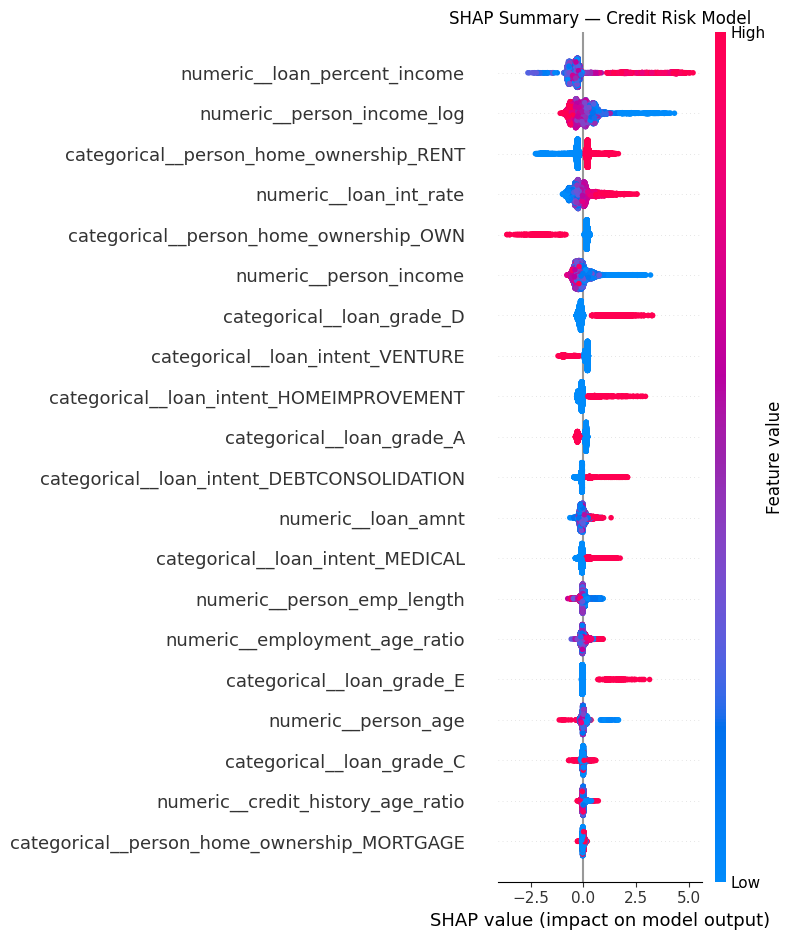

In [79]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary — Credit Risk Model"
)

plt.tight_layout()
plt.show()

In [80]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(
        shap_values
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
6,numeric__loan_percent_income,0.778178
2,numeric__person_income_log,0.446782
13,categorical__person_home_ownership_RENT,0.410025
5,numeric__loan_int_rate,0.396188
12,categorical__person_home_ownership_OWN,0.333003
1,numeric__person_income,0.312076
23,categorical__loan_grade_D,0.295310
19,categorical__loan_intent_VENTURE,0.268771
16,categorical__loan_intent_HOMEIMPROVEMENT,0.195035
20,categorical__loan_grade_A,0.168170


## 18.2 Local SHAP Explanation

Global explanations describe overall model behavior.

Local explanations investigate an individual prediction.

For a selected applicant, SHAP values show which features pushed the prediction toward higher or lower default risk.

This is particularly useful in credit-risk applications where individual decisions may require explanation.

In [81]:
sample_index = 0

print(
    "Predicted probability:",
    final_candidate_probabilities[sample_index]
)

print(
    "Actual class:",
    y_test.iloc[sample_index]
)

Predicted probability: 0.29367501181887207
Actual class: 0


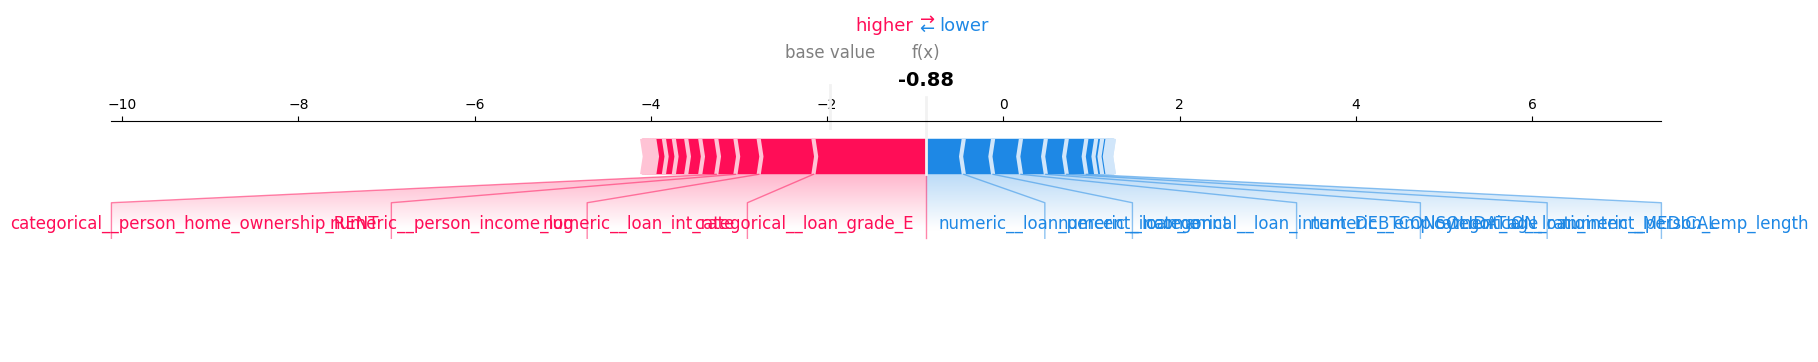

<Figure size 640x480 with 0 Axes>

In [82]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    feature_names=feature_names,
    matplotlib=True
)

plt.tight_layout()
plt.show()

# 19. Save Final Model Artifacts

The final model and preprocessing pipeline will be saved as separate artifacts.

Both are required for production inference.

### Required Artifacts

1. Preprocessing pipeline
2. Trained machine-learning model
3. Classification threshold

The preprocessing pipeline ensures incoming applicant data is transformed consistently with the training data.

The model generates the default probability.

The threshold converts the probability into the final business classification.

In [83]:
joblib.dump(
    final_candidate_model,
    "../models/credit_risk_model.pkl"
)

print(
    "Credit Risk model saved successfully."
)

Credit Risk model saved successfully.


In [84]:
joblib.dump(
    best_threshold,
    "../models/credit_risk_threshold.pkl"
)

print(
    "Classification threshold saved:",
    best_threshold
)

Classification threshold saved: 0.46


In [85]:
import os

model_path = "../models/credit_risk_model.pkl"
preprocessor_path = "../models/credit_preprocessor.pkl"
threshold_path = "../models/credit_risk_threshold.pkl"

print(
    "Model exists:",
    os.path.exists(model_path)
)

print(
    "Preprocessor exists:",
    os.path.exists(preprocessor_path)
)

print(
    "Threshold exists:",
    os.path.exists(threshold_path)
)

Model exists: True
Preprocessor exists: True
Threshold exists: True


In [86]:
loaded_model = joblib.load(
    "../models/credit_risk_model.pkl"
)

loaded_preprocessor = joblib.load(
    "../models/credit_preprocessor.pkl"
)

loaded_threshold = joblib.load(
    "../models/credit_risk_threshold.pkl"
)

print("All artifacts loaded successfully.")
print("Loaded threshold:", loaded_threshold)

All artifacts loaded successfully.
Loaded threshold: 0.46


In [87]:
sample_applicant = X_test.iloc[[0]].copy()

sample_processed = loaded_preprocessor.transform(
    sample_applicant
)

sample_probability = loaded_model.predict_proba(
    sample_processed
)[:, 1][0]

sample_prediction = int(
    sample_probability >= loaded_threshold
)

print(
    "Default probability:",
    sample_probability
)

print(
    "Classification threshold:",
    loaded_threshold
)

print(
    "Predicted class:",
    sample_prediction
)

Default probability: 0.29367501181887207
Classification threshold: 0.46
Predicted class: 0


# 20. Credit Risk Modeling — Final Conclusion

The Credit Risk machine-learning workflow developed and evaluated multiple classification models for predicting loan default.

### Models Evaluated

- Logistic Regression
- Weighted Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Tuned Random Forest
- Tuned Gradient Boosting

### Final Candidate

The Tuned Gradient Boosting model was selected as the leading candidate based on its overall holdout-test performance.

Its initial test-set performance was:

- Accuracy: **93.75%**
- Precision: **97.29%**
- Recall: **73.48%**
- F1-score: **83.73%**
- ROC-AUC: **94.41%**
- PR-AUC: **90.25%**

The classification threshold was subsequently evaluated to identify a suitable precision-recall trade-off.

### Explainability

Model behavior was investigated using:

- Built-in feature importance
- SHAP global explanations
- SHAP local explanations

### Production Artifacts

The following artifacts were saved:

- `credit_preprocessor.pkl`
- `credit_risk_model.pkl`
- `credit_risk_threshold.pkl`

These artifacts can be reused during deployment so that new applicant data follows the same preprocessing and prediction process used during model development.

### Important Limitations

The model's predictions represent statistical patterns learned from historical data.

Model performance on a holdout dataset does not guarantee equivalent performance in production.

Before deployment, the model should undergo:

- Additional validation
- Data-drift monitoring
- Bias/fairness assessment
- Business-cost analysis
- Security review
- Production monitoring

### Next Stage

The next stage of the project will develop the Fraud Detection machine-learning pipeline.

The Fraud Detection dataset presents a substantially more severe class-imbalance problem, with fraud representing approximately **0.173%** of all transactions.

Therefore, the fraud modeling strategy will require different evaluation metrics and imbalance-handling techniques.